# 02 - Baselines and evaluation protocols
Constant prediction, LASSO and Ridge regression, evaluated under two protocols:

* **kfold** - shuffled 5-fold CV, repeated 3 times (the reference paper's protocol)
* **lodo** - leave-one-day-out CV: train on 4 days, test on the unseen day (our stricter protocol)

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))
warnings.filterwarnings('ignore')
from dataclasses import replace
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from src.baselines import BASELINES, LASSO_ALPHAS, make_lasso
from src.config import FEATURE_GROUPS, FIGURES_DIR
from src.data import load_all
from src.evaluation import PROTOCOLS, cross_validate_model
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
datasets = load_all()

## Baseline MSE for every subject, feature set and protocol

In [2]:
rows = []
for subject, data in datasets.items():
    for fs in FEATURE_GROUPS:
        for protocol in PROTOCOLS:
            for name, factory in BASELINES.items():
                res = cross_validate_model(factory(), data.subset(fs), protocol)
                rows.append(dict(subject=subject, feature_set=fs, protocol=protocol, model=name, mse=res.mse))
baselines = pd.DataFrame(rows)
baselines.pivot_table(index=['subject', 'feature_set'], columns=['protocol', 'model'], values='mse').round(4)

protocol               kfold                     lodo                
model               constant   lasso   ridge constant   lasso   ridge
subject feature_set                                                  
S1      all           0.0666  0.0091  0.0086   0.0917  0.0205  0.0143
        emg           0.0666  0.0186  0.0185   0.0917  0.0636  0.0579
        step          0.0666  0.0215  0.0199   0.0917  0.0352  0.0363
        step_emg      0.0666  0.0099  0.0093   0.0917  0.0260  0.0164
S2      all           0.0362  0.0135  0.0146   0.0478  0.0309  0.0358
        emg           0.0362  0.0181  0.0174   0.0478  0.0444  0.0449
        step          0.0362  0.0216  0.0212   0.0478  0.0476  0.0541
        step_emg      0.0362  0.0145  0.0144   0.0478  0.0448  0.0493

**Reading the table**: the constant model's MSE equals the target variance. Regularised linear models cut the random-k-fold error by roughly 60-85% (S1 LASSO about 0.009, matching the paper's 0.0089), but the error roughly doubles when a whole day is held out.

## Error on each held-out day (LASSO, all features)

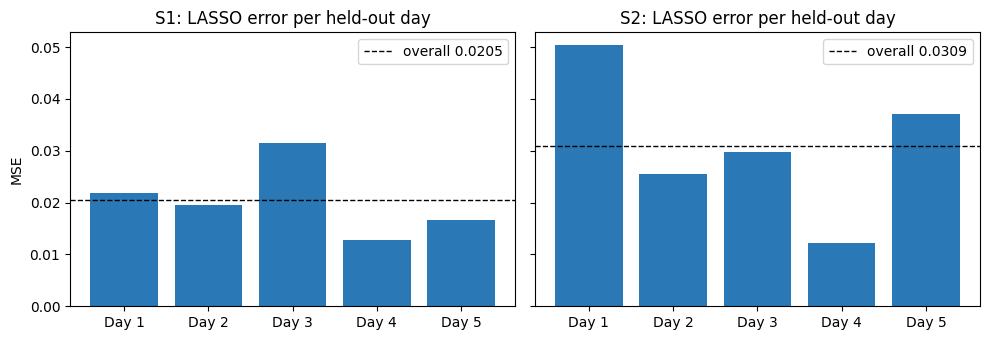

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
for ax, (subject, data) in zip(axes, datasets.items()):
    res = cross_validate_model(make_lasso(), data, 'lodo')
    ax.bar([f'Day {k + 1}' for k in range(len(res.fold_mse))], res.fold_mse, color='#2a78b5')
    ax.axhline(res.mse, color='k', ls='--', lw=1, label=f'overall {res.mse:.4f}')
    ax.set_title(f'{subject}: LASSO error per held-out day')
    ax.legend()
axes[0].set_ylabel('MSE')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'baseline_lodo_per_day.png', dpi=150)
plt.show()

## Why scaling must happen inside the CV loop
The reference code standardised the whole dataset before splitting it. Under leave-one-day-out this leaks the held-out day's mean and spread into training. We compare that against our pipeline, which fits the scaler on training folds only.

In [4]:
rows = []
for subject, data in datasets.items():
    leaky_data = replace(data, X=StandardScaler().fit_transform(data.X))
    leaky_model = LassoCV(alphas=LASSO_ALPHAS, cv=5, max_iter=50_000)
    for protocol in PROTOCOLS:
        rows.append(dict(subject=subject, protocol=protocol,
                         correct_pipeline=cross_validate_model(make_lasso(), data, protocol).mse,
                         scaled_before_split=cross_validate_model(leaky_model, leaky_data, protocol).mse))
pd.DataFrame(rows).round(4)

,subject,protocol,correct_pipeline,scaled_before_split
0,S1,kfold,0.0091,0.0091
1,S1,lodo,0.0205,0.0219
2,S2,kfold,0.0135,0.0137
3,S2,lodo,0.0309,0.0243


With random k-fold the difference is negligible, but under leave-one-day-out the leaky version looks noticeably better for S2 - an over-optimistic number that the correct pipeline avoids.